Regions are defined as in https://www.fao.org/3/k7930e/k7930e00.pdf (Annex 5)

Referenced here:https://foodandagricultureorganization.shinyapps.io/GLEAMV3_Public/

In [1]:
import pandas as pd
import geopandas as gpd

In [2]:


# Loading shapefiles
shp_file_path = '../../data/raw/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp'
dbf_file_path = '../../data/raw/ne_10m_admin_0_countries/ne_10m_admin_0_countries.dbf'
shx_file_path = '../../data/raw/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shx'


world = gpd.read_file(shp_file_path)


world.head()


,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,0,2,Indonesia,IDN,0,2,Sovereign country,1,Indonesia,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4..."
1,Admin-0 country,0,3,Malaysia,MYS,0,2,Sovereign country,1,Malaysia,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4..."
2,Admin-0 country,0,2,Chile,CHL,0,2,Sovereign country,1,Chile,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."
3,Admin-0 country,0,3,Bolivia,BOL,0,2,Sovereign country,1,Bolivia,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5..."
4,Admin-0 country,0,2,Peru,PER,0,2,Sovereign country,1,Peru,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832..."


In [3]:

regions_countries_dict = {
    "Central & South America": [
        "Anguilla", "Antigua and Barbuda", "Argentina", "Aruba", "The Bahamas", "Barbados", "Belize",
        "Bolivia", "Brazil", "British Virgin Islands", "Cayman Islands", "Chile", "Colombia",
        "Costa Rica", "Cuba", "Dominica", "Dominican Republic", "Ecuador", "El Salvador",
        "Falkland Islands", "French Guiana", "Grenada", "Guadeloupe", "Guatemala",
        "Guyana", "Haiti", "Honduras", "Jamaica", "Martinique", "Mexico", "Montserrat",
        "Netherlands Antilles", "Nicaragua", "Panama", "Paraguay", "Peru", "Puerto Rico", "Sint Maarten",
        "Saint Kitts and Nevis", "Saint Lucia", "Saint Martin", "Saint Vincent and the Grenadines", "Suriname",
        "Trinidad and Tobago", "Turks and Caicos Islands", "United States Virgin Islands", "Uruguay",
        "Venezuela", "US Naval Base Guantanamo Bay", "Brazilian Island", "Southern Patagonian Ice Field", "Curaçao",
        "Saint Barthelemy"
    ],
    "Sub-Saharan Africa": [
        "Angola", "Benin", "Botswana", "Burkina Faso", "Burundi", "Ivory Coast", "Cameroon",
        "Cape Verde", "Central African Republic", "Chad", "Comoros", "Congo", "Democratic Republic of the Congo",
        "Republic of the Congo", "Djibouti", "Equatorial Guinea", "Eritrea", "Ethiopia", "Gabon", "Gambia", "Ghana",
        "Guinea", "Guinea-Bissau", "Kenya", "Lesotho", "Liberia", "Madagascar", "Malawi",
        "Mali", "Mauritania", "Mauritius", "Mayotte", "Mozambique", "Namibia", "Niger",
        "Nigeria", "Rwanda", "Reunion", "Saint Helena", "São Tomé and Principe", "Senegal",
        "Seychelles", "Sierra Leone", "Somalia", "Somaliland", "South Africa", "South Sudan", "Swaziland", "Togo",
        "Uganda", "United Republic of Tanzania", "Zambia", "Zimbabwe",  "eSwatini", "Bir Tawil"
    ],
    "West Asia & Northern Africa": [
        "Algeria", "Armenia", "Azerbaijan", "Bahrain", "Cyprus", "Northern Cyprus", "Cyprus No Mans Area", 
        "Dhekelia Sovereign Base Area", "Egypt", "Gaza Strip", "Georgia",
        "Iraq", "Israel", "Jordan", "Kazakhstan", "Kuwait", "Kyrgyzstan", "Lebanon", "Libya",
        "Morocco", "Oman", "Qatar", "Saudi Arabia", "Sudan", "Syria", "Tajikistan",
        "Tunisia", "Turkey", "Turkmenistan", "United Arab Emirates", "Uzbekistan", "West Bank",
        "Western Sahara", "Yemen", "Palestine", "Baykonur Cosmodrome", "Akrotiri Sovereign Base Area"
    ],
    "South Asia": [
        "Afghanistan", "Bangladesh", "Bhutan", "British Indian Ocean Territory", "India",
        "Iran", "Nepal", "Pakistan", "Sri Lanka", "Siachen Glacier"
    ],
    "Eastern Europe": [
        "Belarus", "Bulgaria", "Czechia", "Hungary", "Moldova", "Poland",
        "Romania", "Slovakia", "Ukraine"
    ],
    "Russian Federation": [
        "Russia"
    ],
    "East Asia": [
        "Brunei", "Cambodia", "China", "Christmas Island", "North Korea",
        "Hong Kong S.A.R.", "Indonesia", "Japan", "Laos", "Malaysia", "Mongolia", "Taiwan",
        "Myanmar", "Philippines", "South Korea", "Singapore", "Thailand", "East Timor", "Vietnam"
    ],
    "Oceania": [
        "American Samoa", "Australia", "Cook Islands", "Fiji", "French Polynesia", "Guam",
        "Kiribati", "Federated States of Micronesia", "New Caledonia", "New Zealand", "Niue",
        "Norfolk Island", "Northern Mariana Islands", "Palau", "Papua New Guinea", "Pitcairn",
        "Saint Pierre and Miquelon", "Samoa", "Solomon Islands", "Tokelau", "Tonga", "Vanuatu", 
        "Wallis and Futuna", "Pitcairn Islands", "Marshall Islands", "Tuvalu", "Nauru"
    ],
    "Western Europe": [
        "Albania", "Andorra", "Austria", "Belgium", "Bosnia and Herzegovina", "Croatia",
        "Denmark", "Estonia", "Faroe Islands", "Finland", "France", "Germany", "Gibraltar", "Greece",
        "Guernsey", "Iceland", "Ireland", "Isle of Man", "Italy", "Jersey", "Latvia",
        "Liechtenstein", "Lithuania", "Luxembourg", "Monaco", "Madeira Islands", "Malta", "Montenegro",
        "Netherlands", "Norway", "Portugal", "Republic of Serbia", "San Marino", "Slovenia",
        "Spain", "Svalbard and Jan Mayen Islands", "Sweden", "Switzerland", "Kosovo",
        "North Macedonia", "Vatican", "United Kingdom"
    ],
    "North America": [
        "Bermuda", "Canada", "Greenland", "United States of America"
    ]
}


In [4]:
# Create a new column 'Region' in the dataframe and initialize with None
world['Region'] = None

# Iterate through the regions_countries_dict to assign regions to the countries in the dataframe
for region, countries in regions_countries_dict.items():
    for country in countries:
        world.loc[world['ADMIN'] == country, 'Region'] = region

# Check how many countries were successfully assigned a region
assigned_regions_count = world['Region'].notnull().sum()
unassigned_countries = world[world['Region'].isnull()]['ADMIN'].tolist()

assigned_regions_count, unassigned_countries


(241,
 ['Antarctica',
  'French Southern and Antarctic Lands',
  'United States Minor Outlying Islands',
  'Heard Island and McDonald Islands',
  'Cabo Verde',
  'Aland',
  'Indian Ocean Territories',
  'Maldives',
  'South Georgia and the Islands',
  'Coral Sea Islands',
  'Spratly Islands',
  'Clipperton Island',
  'Macao S.A.R',
  'Ashmore and Cartier Islands',
  'Bajo Nuevo Bank (Petrel Is.)',
  'Serranilla Bank',
  'Scarborough Reef'])

In [6]:

# Function to get the region for a country
def get_region(country):
    for region, countries in regions_countries_dict.items():
        if country in countries:
            return region
    return None  # If the country was not found in the dictionary



# Create a new column for the region
world['Region'] = world['ADMIN'].apply(get_region)

# Save the GeoDataFrame with the new 'Region' column to a new shapefile
world.to_file('../../data/processed/country_boundary.gpkg', layer='countries', driver="GPKG")

# Dissolve countries by region to show regional borders
regions = world.dissolve(by='Region').reset_index()

# Save the GeoDataFrame with regional borders to a Geopackage
regions.to_file('../../data/processed/region_boundary.gpkg', layer='regions', driver="GPKG")

print("Geopackage with region borders saved successfully.")

print("Shapefile with regions saved successfully.")


Geopackage with region borders saved successfully.
Shapefile with regions saved successfully.


In [7]:
world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry,Region
0,Admin-0 country,0,2,Indonesia,IDN,0,2,Sovereign country,1,Indonesia,...,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4...",East Asia
1,Admin-0 country,0,3,Malaysia,MYS,0,2,Sovereign country,1,Malaysia,...,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4...",East Asia
2,Admin-0 country,0,2,Chile,CHL,0,2,Sovereign country,1,Chile,...,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611...",Central & South America
3,Admin-0 country,0,3,Bolivia,BOL,0,2,Sovereign country,1,Bolivia,...,None,None,None,None,None,None,None,None,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5...",Central & South America
4,Admin-0 country,0,2,Peru,PER,0,2,Sovereign country,1,Peru,...,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832...",Central & South America


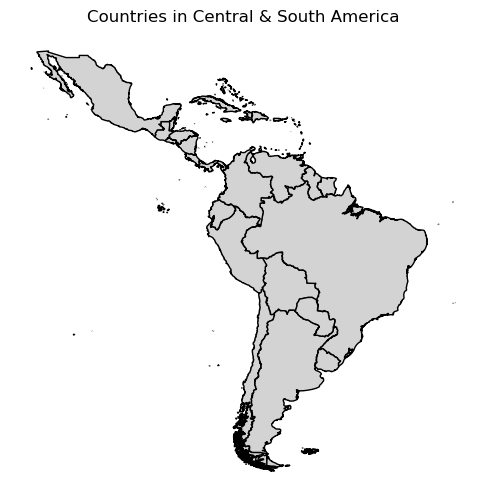

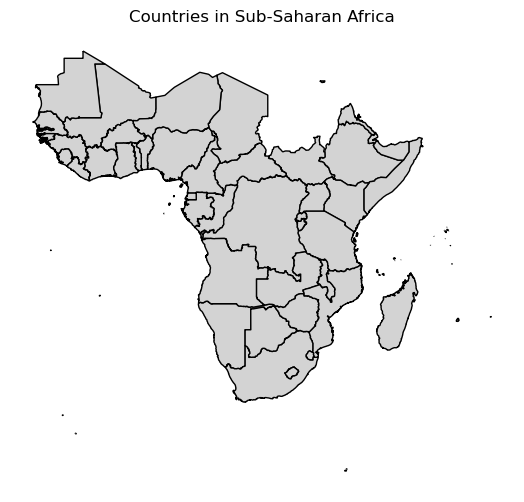

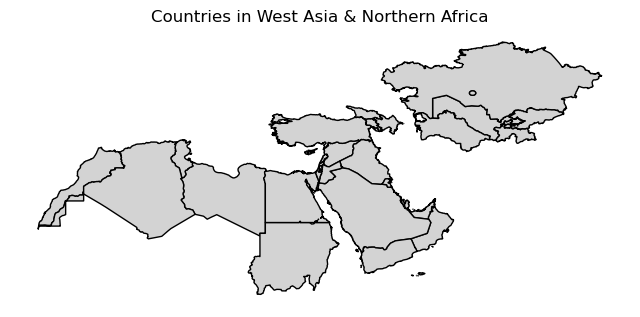

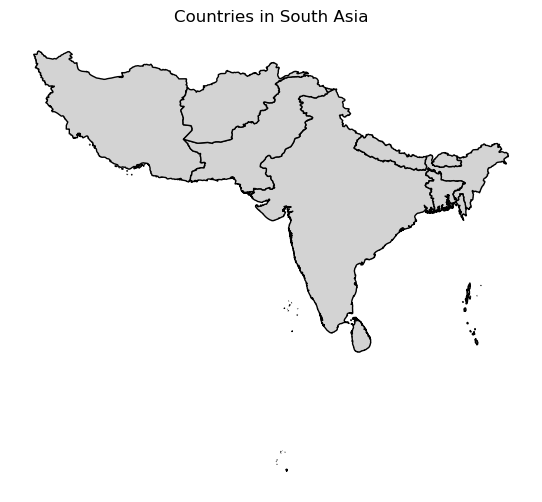

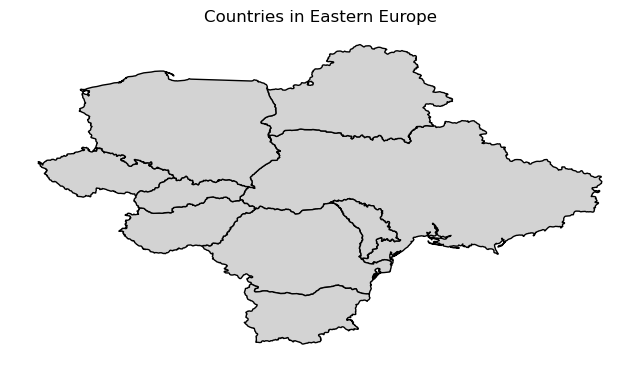

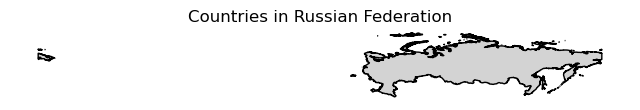

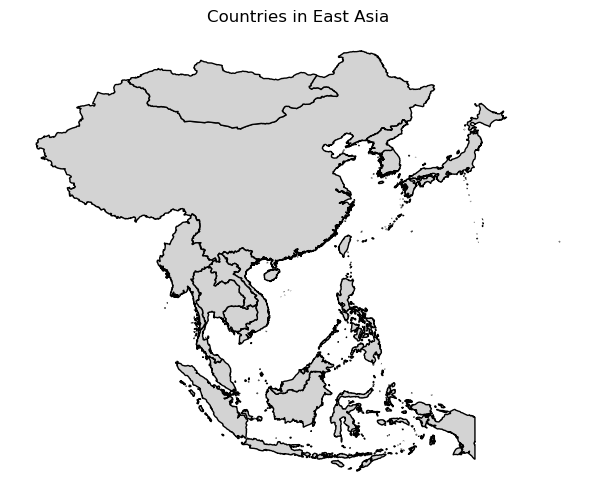

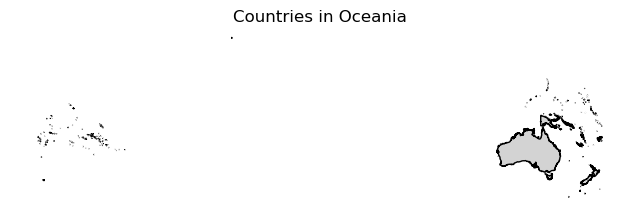

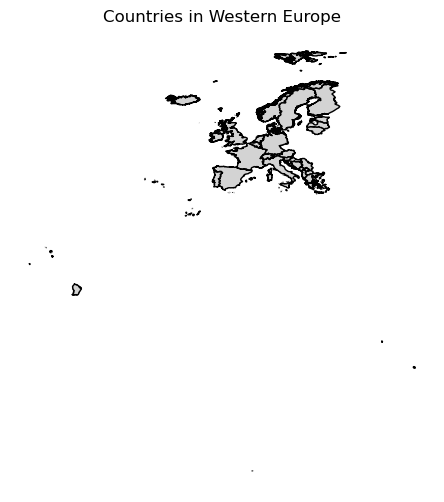

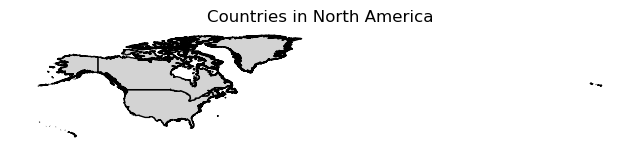

In [8]:
import matplotlib.pyplot as plt

# Iterate over each region and plot
for region in regions_countries_dict.keys():
    # Filter the GeoDataFrame for the current region
    region_data = world[world['Region'] == region]

    
    fig, ax = plt.subplots(figsize=(8, 6))
    region_data.plot(ax=ax, color='lightgrey', edgecolor='black')
    
    
    ax.set_title(f'Countries in {region}')
    ax.axis('off')

    plt.show()


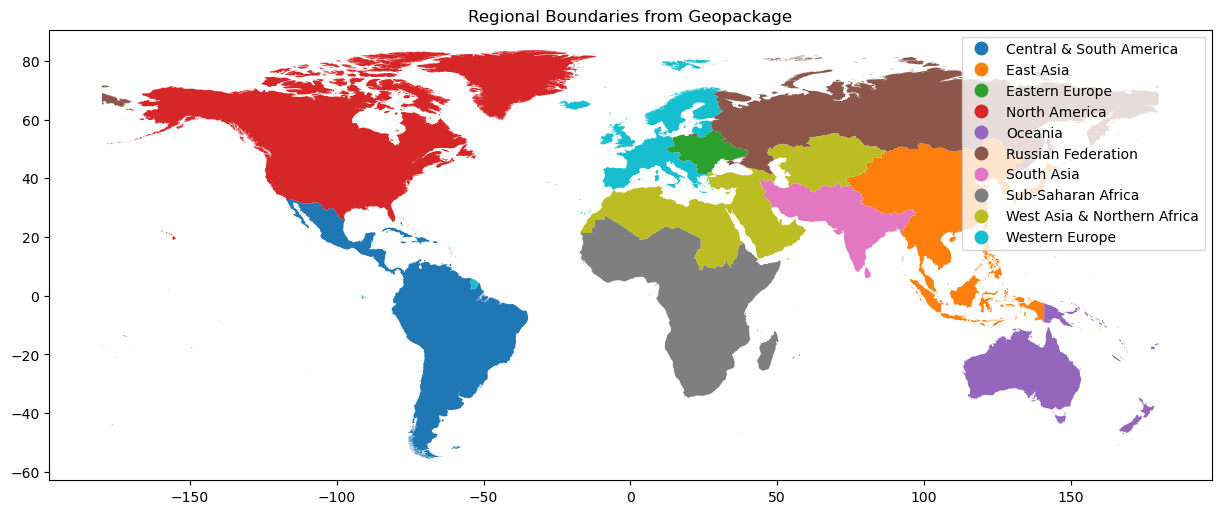

In [10]:
# Path to Geopackage file containing the regions
gpkg_file_path = '../../data/processed/region_boundary.gpkg'

regions = gpd.read_file(gpkg_file_path, layer='regions')

# Plot each region with a different color
fig, ax = plt.subplots(figsize=(15, 10))
regions.plot(ax=ax, column='Region', legend=True, legend_kwds={'bbox_to_anchor': (1, 1)})
plt.title('Regional Boundaries from Geopackage')
plt.show()
